In [1]:
# 1) Core imports and configuration

import os
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

# --- ADDED: Scenario 3 Output Directory ---
SAVE_DIR = "results/scenario3"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Results will be saved to: {SAVE_DIR}")
# ------------------------------------------

# EdgeSimPy — correct import pattern
try:
    from edge_sim_py import *
    import edge_sim_py as EDGESIMPY_MODULE
    # Verify Simulator is actually available after wildcard import
    if "Simulator" not in dir():
        raise ImportError("Simulator class not found after edge_sim_py wildcard import.")
    print(f"EdgeSimPy available: {EDGESIMPY_MODULE.__version__ if hasattr(EDGESIMPY_MODULE, '__version__') else 'version unknown'}")
except ImportError as e:
    raise ImportError(
        "EdgeSimPy is not installed or not visible in this environment.\n"
        "Run:  pip install git+https://github.com/EdgeSimPy/EdgeSimPy.git\n"
        "Then restart the kernel."
    ) from e

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print(f"PyTorch:    {torch.__version__}")
print(f"Gymnasium:  {gym.__version__}")
print(f"Device:     {DEVICE}")

Results will be saved to: results/scenario3
EdgeSimPy available: 1.1.0
PyTorch:    2.10.0+cpu
Gymnasium:  1.2.3
Device:     cpu


In [2]:
# 2) Global configuration and infrastructure spec

@dataclass(frozen=True)
class GlobalConfig:
    # Infrastructure
    EDGE_SERVER_COUNT: int = 10
    CLOUD_SERVER_COUNT: int = 1
    EDGE_CPU_MIPS: float = 2000.0
    CLOUD_CPU_MIPS: float = 25000.0
    EDGE_CLOUD_BANDWIDTH_MBPS: float = 100.0

    # Task model
    TASK_SIZE_MB: float = 0.5
    TASK_COMPLEXITY_GIGACYCLES: float = 1.0

    # Paths (CHANGED: mapped to S3)
    RESULTS_DIR: str = SAVE_DIR
    SCENARIO_FILE: str = f"results/edgesimpy/scenario3.json"

    # RL defaults
    GAMMA: float = 0.99
    ACTOR_LR: float = 1e-4
    CRITIC_LR: float = 1e-4
    BATCH_SIZE: int = 64
    MEMORY_CAPACITY: int = 50_000

    # Experiment seeds
    SEEDS: Tuple[int, ...] = (10, 20, 30, 40, 50)

CONFIG = GlobalConfig()

# Expose seeds as a list for loops
EXPERIMENT_SEEDS = list(CONFIG.SEEDS)

Path(CONFIG.RESULTS_DIR).mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class InfrastructureSpec:
    edge_server_count: int          = CONFIG.EDGE_SERVER_COUNT
    cloud_server_count: int         = CONFIG.CLOUD_SERVER_COUNT
    edge_cpu_mips: float            = CONFIG.EDGE_CPU_MIPS
    cloud_cpu_mips: float           = CONFIG.CLOUD_CPU_MIPS
    edge_cloud_bandwidth_mbps: float = CONFIG.EDGE_CLOUD_BANDWIDTH_MBPS
    task_size_mb: float             = CONFIG.TASK_SIZE_MB
    task_complexity_gigacycles: float = CONFIG.TASK_COMPLEXITY_GIGACYCLES
    dataset_dir: str                = CONFIG.RESULTS_DIR
    dataset_file: str               = CONFIG.SCENARIO_FILE

INFRA = InfrastructureSpec()
print("Config and infrastructure spec ready.")
print(f"Results Directory: {CONFIG.RESULTS_DIR}")
print(f"Seeds: {EXPERIMENT_SEEDS}")
print(f"Device: {DEVICE}")

Config and infrastructure spec ready.
Results Directory: results/scenario3
Seeds: [10, 20, 30, 40, 50]
Device: cpu


In [3]:
# 3) Build and save EdgeSimPy scenario JSON (infrastructure only)

def build_edgesimpy_dataset(spec: InfrastructureSpec) -> Dict[str, Any]:
    edge_servers = [
        {
            "attributes": {
                "id": i + 1,
                "model_name": f"edge_{i + 1}",
                "cpu": spec.edge_cpu_mips,
            },
            "relationships": {},
        }
        for i in range(spec.edge_server_count)
    ]

    cloud_servers = [
        {
            "attributes": {
                "id": 10_000 + i + 1,
                "model_name": f"cloud_{i + 1}",
                "cpu": spec.cloud_cpu_mips,
            },
            "relationships": {},
        }
        for i in range(spec.cloud_server_count)
    ]

    dataset = {
        "metadata": {
            "edge_server_count": spec.edge_server_count,
            "cloud_server_count": spec.cloud_server_count,
            "edge_cloud_bandwidth_mbps": spec.edge_cloud_bandwidth_mbps,
            "task_size_mb": spec.task_size_mb,
            "task_complexity_gigacycles": spec.task_complexity_gigacycles,
        },
        "edge_servers": edge_servers,
        "cloud_servers": cloud_servers,
    }

    return dataset


EDGE_DATASET = build_edgesimpy_dataset(INFRA)

with open(INFRA.dataset_file, "w", encoding="utf-8") as f:
    json.dump(EDGE_DATASET, f, indent=2)

print(f"EdgeSimPy scenario written to: {INFRA.dataset_file}")
print(f"Edge servers: {INFRA.edge_server_count}, cloud servers: {INFRA.cloud_server_count}")

EdgeSimPy scenario written to: results/edgesimpy/scenario3.json
Edge servers: 10, cloud servers: 1


In [4]:
# 4) EdgeSimPy–Gymnasium environment wrapper (scheduling env)

class EdgeSimPySchedulingEnv(gym.Env):
    """Binary edge/cloud scheduling environment backed by EdgeSimPy.
    
    State space (5D):
        [queue_avg, workload_norm, pressure_norm, lat_weight, energy_cost_norm]
        - queue_avg       : current queue backlog (0–300)
        - workload_norm   : normalised task arrival rate (0–1)
        - pressure_norm   : load above baseline, normalised (0–1)
        - lat_weight      : current latency objective weight from DynamicWeightController (0–1)
        - energy_cost_norm: last-step energy cost, normalised (0–1)
    """

    metadata = {"render_modes": ["human"], "render_fps": 1}

    def __init__(
        self,
        scenario_config=None,
        spec: InfrastructureSpec = INFRA,
        scenario_file: Optional[str] = None,
        render_mode: Optional[str] = None,
    ):
        super().__init__()

        self.spec = spec
        self.scenario_config = scenario_config
        self.scenario_file = scenario_file or getattr(CONFIG, "EDGESIMPY_SCENARIO_FILE", None)
        self.render_mode = render_mode

        # RL interface
        self.action_space = spaces.Discrete(2)          # 0 = edge, 1 = cloud
        self.observation_space = spaces.Box(            # 5D
            low=np.array( [0.0,   0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([300.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        # Internal state
        self.simulator: Optional[Simulator] = None
        self.pending_action: int   = 0
        self.episodelength: int    = 2000
        self.stepcount: int        = 0
        self.currentworkload: int  = 50
        self.queueavg: float       = 10.0
        self.last_latency_s: float = 0.0
        self.last_energy_j: float  = 0.0
        self.current_lat_weight: float = 0.3   # ← NEW: updated externally by DynamicWeightController

    # ── Weight interface ──────────────────────────────────────────────────────

    def update_weights(self, lat_weight: float, eng_weight: float) -> None:  # ← NEW
        """Called by DynamicWeightController after each weight update.
        Exposes current objective priority to the agent's policy network.
        Required per Abels et al. (2019) §3 for weight-conditioned policy learning.
        """
        self.current_lat_weight = float(np.clip(lat_weight, 0.0, 1.0))

    # ── EdgeSimPy integration helpers ─────────────────────────────────────────

    def _build_simulator(self) -> Optional[Simulator]:
        if self.scenario_file is None or not os.path.exists(self.scenario_file):
            return None
        try:
            sim = Simulator(
                tick_duration=1,
                tick_unit="seconds",
                resource_management_algorithm=self._resource_management_algorithm,
            )
            try:
                sim.initialize(input_file=self.scenario_file)
            except TypeError:
                sim.initialize(self.scenario_file)
            return sim
        except Exception:
            return None

    def _resource_management_algorithm(self, parameters=None):
        if parameters is None:
            parameters = {}

        action      = int(parameters.get("action", self.pending_action))
        target_tier = "edge" if action == 0 else "cloud"

        EdgeServer = getattr(EDGESIMPY_MODULE, "EdgeServer", None)
        Service    = getattr(EDGESIMPY_MODULE, "Service",    None)

        if EdgeServer is None or Service is None:
            return {"action": action, "target_tier": target_tier, "placements": 0}

        try:
            servers  = list(EdgeServer.all())
            services = list(Service.all())
        except Exception:
            return {"action": action, "target_tier": target_tier, "placements": 0}

        def is_tier(server, tier: str) -> bool:
            name = str(getattr(server, "model_name", "")).lower()
            if tier == "cloud":
                return "cloud" in name or int(getattr(server, "id", 0)) >= 10_000
            return "edge" in name or int(getattr(server, "id", 0)) < 10_000

        def free_cpu(server) -> float:
            total = float(getattr(server, "cpu", 0.0))
            used  = float(getattr(server, "cpu_demand",
                          getattr(server, "cpu_used", 0.0)))
            return total - used

        candidates = sorted(
            [s for s in servers if is_tier(s, target_tier)],
            key=free_cpu, reverse=True,
        )

        placements = 0
        for svc in services:
            if getattr(svc, "server", None) is not None:
                continue
            if bool(getattr(svc, "finished", False)):
                continue
            for srv in candidates:
                fn = getattr(srv, "provision", None)
                if callable(fn):
                    try:
                        fn(service=svc)
                    except TypeError:
                        try:
                            fn(svc)
                        except Exception:
                            continue
                    placements += 1
                    break

        return {"action": action, "target_tier": target_tier, "placements": placements}

    def _advance_simulator_one_tick(self) -> None:
        if self.simulator is None:
            return
        if hasattr(self.simulator, "step") and callable(self.simulator.step):
            self.simulator.step()
        elif hasattr(self.simulator, "run_step") and callable(self.simulator.run_step):
            self.simulator.run_step()

    def _get_workload(self, timestep: int) -> int:
        if self.scenario_config is None:
            return int(self.currentworkload)
        if hasattr(self.scenario_config, "workload_at"):
            return int(self.scenario_config.workload_at(timestep))
        raise AttributeError("ScenarioConfig must define workload_at()")

    # ── Analytical latency / energy model ────────────────────────────────────

    def _compute_metrics(self, action: int) -> Tuple[float, float]:
        edge_total_mips  = self.spec.edge_server_count  * self.spec.edge_cpu_mips
        cloud_total_mips = self.spec.cloud_server_count * self.spec.cloud_cpu_mips
        cycles           = self.spec.task_complexity_gigacycles * 1e9

        edge_compute_base_s  = cycles / (edge_total_mips  * 1e6)
        cloud_compute_base_s = cycles / (cloud_total_mips * 1e6)
        transmission_base_s  = (self.spec.task_size_mb * 8.0) / self.spec.edge_cloud_bandwidth_mbps

        edge_latency_s = edge_compute_base_s * (
            1.0 + self.queueavg / 80.0 + self.currentworkload / 250.0
        )
        cloud_latency_s = (transmission_base_s + cloud_compute_base_s) * (
            1.0 + self.queueavg / 220.0 + self.currentworkload / 400.0
        )

        edge_energy_j  = 1.6 * edge_latency_s  + 0.002  * self.currentworkload
        cloud_energy_j = 0.8 * cloud_latency_s + 0.0008 * self.currentworkload

        if int(action) == 0:
            return float(edge_latency_s), float(edge_energy_j)
        return float(cloud_latency_s), float(cloud_energy_j)

    def _build_state(self) -> np.ndarray:                              # ← CHANGED
        workload_norm    = min(float(self.currentworkload) / 150.0, 1.0)
        pressure_norm    = min(max((float(self.currentworkload) - 50.0) / 100.0, 0.0), 1.0)
        energy_cost_norm = min(float(self.last_energy_j) / 5.0, 1.0)  # ceiling 5J [ASSUMED]
        return np.array(
            [float(self.queueavg), workload_norm, pressure_norm,
             self.current_lat_weight, energy_cost_norm],
            dtype=np.float32,
        )

    # ── Gymnasium API ─────────────────────────────────────────────────────────

    def reset(
        self,
        *,
        seed: Optional[int] = None,
        options: Optional[Dict[str, Any]] = None,
        episodelength: Optional[int] = None,
        initialworkload: Optional[int] = None,
    ):
        super().reset(seed=seed)
        if seed is not None:
            set_global_seed(seed)

        options = options or {}
        self.episodelength = int(
            episodelength if episodelength is not None
            else options.get("episodelength", self.episodelength)
        )
        self.currentworkload = int(
            initialworkload if initialworkload is not None
            else options.get("initialworkload", 50)
        )

        self.stepcount          = 0
        self.queueavg           = 10.0 + 0.10 * max(0, self.currentworkload - 50)
        self.last_latency_s     = 0.0
        self.last_energy_j      = 0.0
        self.pending_action     = 0
        self.current_lat_weight = 0.3   # ← NEW: reset to initial prior

        self.simulator = self._build_simulator()

        obs  = self._build_state()
        info = {
            "queueavg":         float(self.queueavg),
            "workloadlevel":    int(self.currentworkload),
            "selectedlatencys": float(self.last_latency_s),
            "selectedenergyj":  float(self.last_energy_j),
            "latencyreward":    float(-self.last_latency_s),
            "energyreward":     float(-self.last_energy_j),
        }
        return obs, info

    def step(self, action: int, workloadlevel: Optional[int] = None):
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action: {action}")

        self.pending_action = action

        if workloadlevel is not None:
            self.currentworkload = int(workloadlevel)
        else:
            self.currentworkload = self._get_workload(self.stepcount)

        offload_relief = 6.0 if action == 1 else 0.0
        queue_next = (
            0.90 * self.queueavg
            + 0.18 * self.currentworkload
            - 8.0
            - offload_relief
        )
        self.queueavg = float(np.clip(queue_next, 0.0, 300.0))

        self.last_latency_s, self.last_energy_j = self._compute_metrics(action)

        latency_reward = -float(self.last_latency_s)
        energy_reward  = -float(self.last_energy_j)
        scalar_reward  = 0.5 * latency_reward + 0.5 * energy_reward

        scheduling_info = self._resource_management_algorithm(
            parameters={"action": self.pending_action}
        )
        self._advance_simulator_one_tick()

        self.stepcount += 1
        terminated = False
        truncated  = self.stepcount >= self.episodelength

        obs  = self._build_state()
        info = {
            "queueavg":         float(self.queueavg),
            "workloadlevel":    int(self.currentworkload),
            "selectedlatencys": float(self.last_latency_s),
            "selectedenergyj":  float(self.last_energy_j),
            "latencyreward":    float(latency_reward),
            "energyreward":     float(energy_reward),
            "placements":       int(scheduling_info.get("placements", 0)),
            "targettier":       scheduling_info.get("target_tier", "edge"),
        }

        return obs, float(scalar_reward), terminated, truncated, info

    def render(self):
        if self.render_mode == "human":
            print(
                f"t={self.stepcount} "
                f"workload={self.currentworkload} "
                f"queue={self.queueavg:.2f} "
                f"latency={self.last_latency_s:.4f}s "
                f"energy={self.last_energy_j:.4f}J "
                f"lat_weight={self.current_lat_weight:.3f}"  # ← NEW: visible in render
            )

    def close(self):
        self.simulator = None

print("Environment wrapper ready:", EdgeSimPySchedulingEnv.__name__)

Environment wrapper ready: EdgeSimPySchedulingEnv


In [5]:
# 5) Actor–Critic neural architecture for MOPER

@dataclass(frozen=True)
class ActorCriticHyperParams:
    actor_learning_rate: float = CONFIG.ACTOR_LR
    critic_learning_rate: float = CONFIG.CRITIC_LR
    gamma: float = CONFIG.GAMMA
    batch_size: int = CONFIG.BATCH_SIZE
    memory_capacity: int = CONFIG.MEMORY_CAPACITY


class MOPERActorCriticNet(nn.Module):
    """
    Shared state encoder, one policy head, two value heads:
    - latency value
    - energy value
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(hidden_dim, action_dim)
        self.latency_value_head = nn.Linear(hidden_dim, 1)
        self.energy_value_head = nn.Linear(hidden_dim, 1)

    def forward(self, state: torch.Tensor):
        z = self.shared(state)
        logits = self.actor_head(z)
        latency_value = self.latency_value_head(z)
        energy_value = self.energy_value_head(z)
        return logits, latency_value, energy_value

    def action_distribution(self, state: torch.Tensor):
        logits, _, _ = self.forward(state)
        return torch.distributions.Categorical(logits=logits)

In [6]:
# 6) Dynamic weight adjustment mechanism

@dataclass(frozen=True)
class WeightControlConfig:
    high_load_threshold: float = 20.0
    low_load_latency_weight: float = 0.30
    high_load_latency_weight: float = 0.80
    adaptation_rate: float = 0.12
    ema_decay: float = 0.96
    ratio_blend: float = 0.15        # pull toward cost-proportional target
    queue_fallback_blend: float = 0.10
    min_latency_weight: float = 0.10
    max_latency_weight: float = 0.90
    
    # ← ADDED: Normalization constants to balance objective scales
    max_latency_cost: float = 0.5
    max_energy_cost: float = 5.0


class DynamicWeightController:
    """
    Maintains latency/energy weights using:
      1. EMA gap signal — reacts to sudden cost shifts (non-stationarity)
      2. Ratio signal  — steady-state pull toward cost-proportional weights
      3. Queue prior   — pressure-based override at high load
    """

    def __init__(self, config: WeightControlConfig = WeightControlConfig()):
        self.config = config
        self.alpha = float(config.low_load_latency_weight)
        self.beta  = 1.0 - self.alpha

        self.latency_ema: Optional[float] = None
        self.energy_ema:  Optional[float] = None
        self.eps = 1e-8

    def _queue_prior(self, current_queue_avg: float) -> float:
        if float(current_queue_avg) >= self.config.high_load_threshold:
            return float(self.config.high_load_latency_weight)
        return float(self.config.low_load_latency_weight)

    def _normalize(self, latency_weight: float) -> Tuple[float, float]:
        lw = float(np.clip(
            latency_weight,
            self.config.min_latency_weight,
            self.config.max_latency_weight,
        ))
        return lw, 1.0 - lw

    def update_from_feedback(
        self,
        latency_cost: float,
        energy_cost: float,
        current_queue_avg: float,
    ) -> Tuple[float, float]:
        
        # ← CHANGED: Normalize costs to 0.0-1.0 range so energy does not dominate latency
        lc_norm = min(float(max(latency_cost, self.eps)) / self.config.max_latency_cost, 1.0)
        ec_norm = min(float(max(energy_cost, self.eps)) / self.config.max_energy_cost, 1.0)

        # Update EMA using normalized costs
        if self.latency_ema is None:
            self.latency_ema = lc_norm
            self.energy_ema  = ec_norm
        else:
            d = self.config.ema_decay
            self.latency_ema = d * self.latency_ema + (1.0 - d) * lc_norm
            self.energy_ema  = d * self.energy_ema  + (1.0 - d) * ec_norm

        # Signal 1: EMA gap — fires when costs deviate from running average
        gap_latency = lc_norm - self.latency_ema
        gap_energy  = ec_norm - self.energy_ema

        self.alpha = self.alpha + self.config.adaptation_rate * (gap_latency - gap_energy)

        # Signal 2: ratio-based target — steady-state adaptation
        total       = self.latency_ema + self.energy_ema + self.eps
        ratio_alpha = self.latency_ema / total   # dynamic, updates every step

        self.alpha = (1.0 - self.config.ratio_blend) * self.alpha + \
                     self.config.ratio_blend * ratio_alpha

        # Signal 3: queue pressure prior
        queue_alpha = self._queue_prior(current_queue_avg)
        self.alpha = (1.0 - self.config.queue_fallback_blend) * self.alpha + \
                     self.config.queue_fallback_blend * queue_alpha

        self.alpha, self.beta = self._normalize(self.alpha)
        return self.alpha, self.beta

    def select_weights(self, current_queue_avg: float) -> Tuple[float, float]:
        """Passive weight selection without feedback — used for inference only."""
        queue_alpha = self._queue_prior(current_queue_avg)
        alpha = (1.0 - self.config.queue_fallback_blend) * self.alpha + \
                self.config.queue_fallback_blend * queue_alpha
        self.alpha, self.beta = self._normalize(alpha)
        return self.alpha, self.beta

print("DynamicWeightController ready.")

DynamicWeightController ready.


In [7]:
# 7) Multi-objective prioritized experience replay (MOPER buffer)

from dataclasses import dataclass
import numpy as np

@dataclass
class ObjectiveTransition:
    state: np.ndarray
    action: int
    latency_reward: float
    energy_reward: float
    scalar_reward: float
    next_state: np.ndarray
    done: bool
    latency_weight: float
    energy_weight: float

class PrioritizedObjectiveReplayBuffer:
    """
    Stores per-objective rewards and priorities.
    Priority is based on combined latency/energy TD components.
    """

    def __init__(self, capacity: int, alpha: float = 0.6, beta: float = 0.4, eps: float = 1e-6):
        if capacity <= 0:
            raise ValueError("capacity must be positive")
        self.capacity = int(capacity)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.eps = float(eps)

        self.memory: list[ObjectiveTransition] = []
        self.priorities = np.zeros(self.capacity, dtype=np.float32)
        self.pos = 0

    def __len__(self) -> int:
        return len(self.memory)

    def max_priority(self) -> float:
        if not self.memory:
            return 1.0
        return float(np.max(self.priorities[: len(self.memory)]))

    def add(self, transition: ObjectiveTransition, priority: float = 1.0) -> None:
        p = max(float(priority), self.eps)
        if len(self.memory) < self.capacity:
            self.memory.append(transition)
        else:
            self.memory[self.pos] = transition
        self.priorities[self.pos] = p
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int):
        if batch_size > len(self.memory):
            raise ValueError("batch_size cannot exceed current buffer size")

        valid_prio = np.maximum(self.priorities[: len(self.memory)], self.eps)
        scaled = np.power(valid_prio, self.alpha)
        total = float(scaled.sum())
        if not np.isfinite(total) or total <= self.eps:
            probs = np.full(len(self.memory), 1.0 / len(self.memory), dtype=np.float32)
        else:
            probs = (scaled / total).astype(np.float32)

        indices = np.random.choice(len(self.memory), size=batch_size, replace=False, p=probs)
        batch = [self.memory[i] for i in indices]

        is_weights = np.power(len(self.memory) * probs[indices] + self.eps, -self.beta)
        is_weights = (is_weights / is_weights.max()).astype(np.float32)

        return batch, indices.astype(np.int64), is_weights

    def update_priorities(self, indices, priorities) -> None:
        for idx, p in zip(indices, priorities):
            self.priorities[int(idx)] = max(float(p), self.eps)

    def boost_all_priorities(self, factor: float = 2.0) -> None:
        """
        Multiply all stored priorities by factor when a regime change is detected.
        Forces the buffer to re-expose all past experiences under the new weights.
        """
        if len(self.memory) == 0:
            return
        n = len(self.memory)
        # Cap at max_priority to prevent runaway values
        current_max = self.max_priority()
        self.priorities[:n] = np.minimum(self.priorities[:n] * factor, current_max * factor)

print("The artefact buffer ready.")

The artefact buffer ready.


In [8]:
# 8) MOPERActorCriticAgent — full artefact

@dataclass(frozen=True)
class MOPERHyperParams:
    actor_lr: float = CONFIG.ACTOR_LR
    critic_lr: float = CONFIG.CRITIC_LR
    gamma: float = CONFIG.GAMMA
    batch_size: int = CONFIG.BATCH_SIZE
    memory_capacity: int = CONFIG.MEMORY_CAPACITY
    per_alpha: float = 0.6       # PER priority exponent
    per_beta: float = 0.4        # IS-weight exponent
    per_eps: float = 1e-6        # floor for zero priority
    grad_clip_norm: float = 0.5

class MOPERActorCriticAgent:
    """
    Multi-Objective Actor-Critic with weight-aware Prioritized Experience Replay.
    Actor:  policy logits (Categorical over edge/cloud)
    Critic: two separate value heads — latency and energy
    Replay: PrioritizedObjectiveReplayBuffer, priorities = joint MO-TD magnitude
    Weights: DynamicWeightController, updated externally via update_weights()
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int = 2,
        hp: MOPERHyperParams = MOPERHyperParams(),
        seed: Optional[int] = None,
    ):
        if state_dim <= 0 or action_dim <= 0:
            raise ValueError("state_dim and action_dim must be positive")
        self.hp = hp
        self.device = DEVICE

        self.net = MOPERActorCriticNet(state_dim, action_dim).to(self.device)

        # Separate optimizers: actor owns shared + actor_head;
        # critic owns shared + both value heads
        self.actor_optimizer = torch.optim.Adam(
            list(self.net.shared.parameters())
            + list(self.net.actor_head.parameters()),
            lr=hp.actor_lr,
        )
        self.critic_optimizer = torch.optim.Adam(
            list(self.net.shared.parameters())
            + list(self.net.latency_value_head.parameters())
            + list(self.net.energy_value_head.parameters()),
            lr=hp.critic_lr,
        )

        self.buffer = PrioritizedObjectiveReplayBuffer(
            capacity=hp.memory_capacity,
            alpha=hp.per_alpha,
            beta=hp.per_beta,
            eps=hp.per_eps,
        )
        self.weight_controller = DynamicWeightController()
        self.latency_weight: float = self.weight_controller.alpha
        self.energy_weight: float = self.weight_controller.beta

        if seed is not None:
            set_global_seed(seed)

    # ── Public API ────────────────────────────────────────────────────────────

    def act(self, state: np.ndarray) -> int:
        state_t = torch.tensor(
            np.asarray(state, dtype=np.float32),
            dtype=torch.float32, device=self.device,
        ).unsqueeze(0)
        with torch.no_grad():
            dist = self.net.action_distribution(state_t)
        return int(dist.sample().item())

    def remember(
        self,
        state: np.ndarray,
        action: int,
        latency_reward: float,
        energy_reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        scalar_reward = (
            self.latency_weight * latency_reward
            + self.energy_weight * energy_reward
        )
        transition = ObjectiveTransition(
            state=np.asarray(state, dtype=np.float32),
            action=int(action),
            latency_reward=float(latency_reward),
            energy_reward=float(energy_reward),
            scalar_reward=float(scalar_reward),
            next_state=np.asarray(next_state, dtype=np.float32),
            done=bool(done),
            latency_weight=self.latency_weight,
            energy_weight=self.energy_weight,
        )
        self.buffer.add(transition, priority=self.buffer.max_priority())

    def update_weights(
        self, latency_cost: float, energy_cost: float, queue_avg: float,
        regime_change_threshold: float = 0.08, # Detects spike onset
        regime_boost_factor: float = 2.0
    ) -> Tuple[float, float]:
        """Call after each env step to adapt objective weights."""
        old_alpha = self.latency_weight
        
        self.latency_weight, self.energy_weight = (
            self.weight_controller.update_from_feedback(
                latency_cost=latency_cost,
                energy_cost=energy_cost,
                current_queue_avg=queue_avg,
            )
        )
        
        # Trigger buffer boost if weights shifted significantly
        delta_alpha = abs(self.latency_weight - old_alpha)
        if delta_alpha > regime_change_threshold and len(self.buffer) > 0:
            self.buffer.boost_all_priorities(factor=regime_boost_factor)
            
        return self.latency_weight, self.energy_weight

    def train_step(self) -> Dict[str, float]:
        if len(self.buffer) < self.hp.batch_size:
            return dict(updated=False, actor_loss=float("nan"),
                        critic_loss=float("nan"), td_error=float("nan"),
                        td_lat=float("nan"), td_eng=float("nan"), # <- Added safe defaults
                        replay_priority=float("nan"))

        batch, indices, is_weights = self.buffer.sample(self.hp.batch_size)

        states      = torch.tensor(np.array([t.state      for t in batch], dtype=np.float32), dtype=torch.float32, device=self.device)
        actions     = torch.tensor([t.action      for t in batch], dtype=torch.long,    device=self.device)
        lat_rewards = torch.tensor([t.latency_reward for t in batch], dtype=torch.float32, device=self.device)
        eng_rewards = torch.tensor([t.energy_reward  for t in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([t.next_state  for t in batch], dtype=np.float32), dtype=torch.float32, device=self.device)
        dones       = torch.tensor([float(t.done)    for t in batch], dtype=torch.float32, device=self.device)
        stored_lw   = torch.tensor([t.latency_weight for t in batch], dtype=torch.float32, device=self.device)
        stored_ew   = torch.tensor([t.energy_weight  for t in batch], dtype=torch.float32, device=self.device)
        isw         = torch.tensor(is_weights, dtype=torch.float32, device=self.device)

        logits, lat_vals, eng_vals = self.net(states)
        lat_vals = lat_vals.squeeze(-1)
        eng_vals = eng_vals.squeeze(-1)

        with torch.no_grad():
            _, next_lat, next_eng = self.net(next_states)
            next_lat = next_lat.squeeze(-1)
            next_eng = next_eng.squeeze(-1)

        lat_targets = lat_rewards + self.hp.gamma * (1.0 - dones) * next_lat
        eng_targets = eng_rewards + self.hp.gamma * (1.0 - dones) * next_eng

        td_lat    = lat_targets - lat_vals
        td_eng    = eng_targets - eng_vals
        td_scalar = stored_lw * td_lat + stored_ew * td_eng   # weight-aware advantage

        # IS-weighted, per-objective critic loss
        critic_loss = (isw * (stored_lw * td_lat.pow(2) + stored_ew * td_eng.pow(2))).mean()

        # Actor loss: policy gradient weighted by MO-advantage
        dist      = torch.distributions.Categorical(logits=logits)
        log_probs = dist.log_prob(actions)
        td_scalar_clamped = td_scalar.detach().clamp(-5.0, 5.0)
        actor_loss = -(log_probs * td_scalar_clamped * isw).mean() - 0.01 * dist.entropy().mean() # entropy bonus prevents collapse

        total_loss = actor_loss + critic_loss

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.net.parameters(), self.hp.grad_clip_norm)
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        # <- CHANGED: Restored the Weight Mismatch Fix for Spikes 2-5
        # Priority update: joint MO-TD magnitude scaled by weight mismatch
        current_lw = torch.tensor(self.latency_weight, dtype=torch.float32, device=self.device)
        weight_mismatch = 1.0 + torch.abs(stored_lw - current_lw)
        
        # Calculate priority and apply mismatch factor
        base_joint_td = torch.sqrt(td_lat.pow(2) + td_eng.pow(2))
        priority_values = (base_joint_td * weight_mismatch).detach().cpu().numpy()
        
        self.buffer.update_priorities(indices, priority_values)

        # <- CHANGED: Added td_lat and td_eng to the return dictionary
        return dict(
            updated=True,
            actor_loss=float(actor_loss.item()),
            critic_loss=float(critic_loss.item()),
            td_error=float(torch.abs(td_scalar).mean().detach().cpu().item()),
            td_lat=float(torch.abs(td_lat).mean().detach().cpu().item()), # PRIMARY METRIC
            td_eng=float(torch.abs(td_eng).mean().detach().cpu().item()), # PRIMARY METRIC
            replay_priority=float(np.mean(priority_values)),
        )

    @property
    def experiment_metadata(self) -> Dict[str, object]:
        return dict(
            algorithm="MOPER",
            actor_lr=self.hp.actor_lr,
            critic_lr=self.hp.critic_lr,
            gamma=self.hp.gamma,
            batch_size=self.hp.batch_size,
            memory_capacity=self.hp.memory_capacity,
            per_alpha=self.hp.per_alpha,
            per_beta=self.hp.per_beta,
        )

print("MOPERActorCriticAgent ready.")

MOPERActorCriticAgent ready.


In [9]:
# 9) Random Agent Baseline

class RandomAgent:
    """
    Random baseline agent. 
    Selects actions uniformly at random (0=edge, 1=cloud).
    Performs no learning. Used to establish the performance floor.
    Must maintain the same API as MOPERActorCriticAgent to work in the shared runner.
    """
    
    def __init__(self, action_dim: int = 2, seed: Optional[int] = None):
        self.action_dim = action_dim
        # Default fixed weights (doesn't use dynamic weighting)
        self.latency_weight = 0.5
        self.energy_weight = 0.5
        
        if seed is not None:
            set_global_seed(seed)
            # Maintain a separate random generator for this agent to ensure exact reproducibility
            self.rng = random.Random(seed)
        else:
            self.rng = random.Random()

    def act(self, state: np.ndarray) -> int:
        """Sample action uniformly at random."""
        return self.rng.randint(0, self.action_dim - 1)

    def remember(
        self,
        state: np.ndarray,
        action: int,
        latency_reward: float,
        energy_reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        """Random agent does not learn; ignores experience."""
        pass

    def update_weights(
        self, latency_cost: float, energy_cost: float, queue_avg: float
    ) -> Tuple[float, float]:
        """Random agent uses fixed weights; no dynamic controller."""
        return self.latency_weight, self.energy_weight

    def train_step(self) -> Dict[str, float]:
        """Random agent does not train; returns empty metrics."""
        return dict(
            updated=False,
            actor_loss=float("nan"),
            critic_loss=float("nan"),
            td_error=float("nan"),
            replay_priority=float("nan"),
        )
        
    @property
    def experiment_metadata(self) -> Dict[str, object]:
        return dict(
            algorithm="Random",
        )

print("RandomAgent ready.")

RandomAgent ready.


In [10]:
# 10) D3QN Agent Baseline (Dual Dueling Deep Q-Network)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
from dataclasses import dataclass
from typing import Dict, Tuple, Optional

@dataclass
class D3QNHyperParams:
    lr: float = 1e-4  # Uses single LR (value-based), avoids the old ACTOR_LR bug
    gamma: float = 0.99
    batch_size: int = 64
    memory_capacity: int = 10000
    target_update_freq: int = 100
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay: int = 1000

class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        # Shared feature encoder
        self.feature_layer = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        # Value stream V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        # Advantage stream A(s, a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        features = self.feature_layer(state)
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)
        # Combine using the Dueling formula
        q_values = values + (advantages - advantages.mean(dim=-1, keepdim=True))
        return q_values

class D3QNAgent:
    """
    D3QN Baseline: Double DQN with Dueling architecture.
    Uses uniform experience replay and a fixed 0.5/0.5 scalarized reward.
    """
    def __init__(self, state_dim: int, action_dim: int = 2, seed: Optional[int] = None):
        self.hp = D3QNHyperParams()
        self.action_dim = action_dim
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        if seed is not None:
            set_global_seed(seed)
            self.rng = random.Random(seed)
        else:
            self.rng = random.Random()

        # Networks
        self.online_net = DuelingQNetwork(state_dim, action_dim).to(self.device)
        self.target_net = DuelingQNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=self.hp.lr)
        self.memory = deque(maxlen=self.hp.memory_capacity)
        
        self.steps_done = 0
        self.epsilon = self.hp.epsilon_start
        
        # Fixed baseline weights
        self.latency_weight = 0.5
        self.energy_weight = 0.5

    def act(self, state: np.ndarray) -> int:
        """Epsilon-greedy action selection."""
        self.steps_done += 1
        # Decay epsilon
        self.epsilon = max(
            self.hp.epsilon_end, 
            self.hp.epsilon_start - self.steps_done / self.hp.epsilon_decay
        )
        
        if self.rng.random() < self.epsilon:
            return self.rng.randint(0, self.action_dim - 1)
            
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.online_net(state_t)
            return int(q_values.argmax(dim=1).item())

    def remember(self, state, action, latency_reward, energy_reward, next_state, done):
        """Stores experience in standard uniform replay using a scalarized reward."""
        # D3QN is architecturally blind to multiple objectives
        scalar_reward = (self.latency_weight * latency_reward) + (self.energy_weight * energy_reward)
        self.memory.append((state, action, scalar_reward, next_state, done))

    def update_weights(self, latency_cost: float, energy_cost: float, queue_avg: float) -> Tuple[float, float]:
        """Returns static weights. D3QN lacks a dynamic controller."""
        return self.latency_weight, self.energy_weight

    def train_step(self) -> Dict[str, float]:
        """Double DQN training step using uniform sampling."""
        if len(self.memory) < self.hp.batch_size:
            return dict(updated=False, actor_loss=float('nan'), critic_loss=float('nan'), td_error=float('nan'), replay_priority=float('nan'))

        # Uniform sampling (No MOPER)
        batch = self.rng.sample(self.memory, self.hp.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states_t = torch.FloatTensor(np.array(states)).to(self.device)
        actions_t = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards_t = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones_t = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Current Q values
        current_q = self.online_net(states_t).gather(1, actions_t)

        # Double DQN target computation
        with torch.no_grad():
            next_actions = self.online_net(next_states_t).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states_t).gather(1, next_actions)
            target_q = rewards_t + (self.hp.gamma * next_q * (1 - dones_t))

        # TD Error and Loss
        td_errors = torch.abs(target_q - current_q).detach().cpu().numpy()
        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optimizer.step()

        # Update target network periodically
        if self.steps_done % self.hp.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return dict(
            updated=True,
            actor_loss=float('nan'),  # D3QN is value-based, no actor loss
            critic_loss=float(loss.item()),
            td_error=float(np.mean(td_errors)),
            replay_priority=1.0  # Uniform replay means all priorities are treated as 1.0
        )

    @property
    def experiment_metadata(self) -> Dict[str, object]:
        return dict(algorithm="D3QN", lr=self.hp.lr, gamma=self.hp.gamma, batch_size=self.hp.batch_size)

print("D3QNAgent ready.")

D3QNAgent ready.


In [11]:
# 12) SAC Agent Baseline (Discrete Soft Actor-Critic)
# Foundational papers: 
# - Haarnoja et al. (2018) for SAC architecture
# - Christodoulou (2019) for discrete action space adaptation

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import copy
import collections
from dataclasses import dataclass
from typing import Dict, Tuple, Optional

@dataclass
class SACHyperParams:
    actor_lr: float = 1e-4
    critic_lr: float = 1e-4
    gamma: float = 0.99
    batch_size: int = 64
    memory_capacity: int = 10000
    tau: float = 0.005           # Polyak averaging coefficient
    alpha: float = 0.2           # Fixed entropy temperature
    grad_clip_norm: float = 0.5

class SACPolicyNet(nn.Module):
    """Stochastic policy network for discrete actions (Categorical distribution)."""
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.distributions.Categorical:
        logits = self.net(x)
        return torch.distributions.Categorical(logits=logits)

    def action_and_log_prob(self, x: torch.Tensor):
        dist = self.forward(x)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, dist

class SACQNet(nn.Module):
    """State-action Q-function for discrete actions. Outputs Q-values for all actions simultaneously."""
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class SACAgent:
    """
    Discrete SAC Baseline.
    Uses uniform experience replay, scalarized reward, and twin Q-networks.
    """
    def __init__(self, state_dim: int, action_dim: int = 2, seed: Optional[int] = None):
        self.hp = SACHyperParams()
        self.action_dim = action_dim
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        if seed is not None:
            self.rng = random.Random(seed)
        else:
            self.rng = random.Random()

        # Actor
        self.actor = SACPolicyNet(state_dim, action_dim).to(self.device)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=self.hp.actor_lr)

        # Twin Critics
        self.q1 = SACQNet(state_dim, action_dim).to(self.device)
        self.q2 = SACQNet(state_dim, action_dim).to(self.device)
        self.q1_target = copy.deepcopy(self.q1).to(self.device)
        self.q2_target = copy.deepcopy(self.q2).to(self.device)
        self.q1_target.eval()
        self.q2_target.eval()

        self.q1_optimizer = optim.Adam(self.q1.parameters(), lr=self.hp.critic_lr)
        self.q2_optimizer = optim.Adam(self.q2.parameters(), lr=self.hp.critic_lr)

        # Uniform replay buffer (No MOPER)
        self.buffer = collections.deque(maxlen=self.hp.memory_capacity)
        
        # Fixed baseline weights
        self.latency_weight = 0.5
        self.energy_weight = 0.5

    def act(self, state: np.ndarray) -> int:
        s = torch.tensor(np.asarray(state), dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            action, _, _ = self.actor.action_and_log_prob(s)
        return int(action.item())

    def remember(self, state, action, latency_reward, energy_reward, next_state, done):
        """Stores experience using a scalarized reward."""
        scalar_reward = (self.latency_weight * latency_reward) + (self.energy_weight * energy_reward)
        self.buffer.append((state, action, scalar_reward, next_state, done))

    def update_weights(self, latency_cost: float, energy_cost: float, queue_avg: float) -> Tuple[float, float]:
        """Returns static weights. SAC lacks a dynamic controller."""
        return self.latency_weight, self.energy_weight

    def soft_update(self, net: nn.Module, target: nn.Module):
        for p, pt in zip(net.parameters(), target.parameters()):
            pt.data.copy_(self.hp.tau * p.data + (1.0 - self.hp.tau) * pt.data)

    def train_step(self) -> Dict[str, float]:
        if len(self.buffer) < self.hp.batch_size:
            return dict(updated=False, actor_loss=float('nan'), critic_loss=float('nan'), 
                        td_error=float('nan'), replay_priority=float('nan'))

        batch = random.sample(self.buffer, self.hp.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states_t = torch.tensor(np.array(states), dtype=torch.float32, device=self.device)
        actions_t = torch.tensor(actions, dtype=torch.long, device=self.device)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        next_states_t = torch.tensor(np.array(next_states), dtype=torch.float32, device=self.device)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=self.device)

        # Step 1: Soft Bellman Target (Christodoulou 2019 eq. 10 - full expectation)
        with torch.no_grad():
            next_dist = self.actor.forward(next_states_t)
            next_probs = next_dist.probs
            next_log_probs = torch.log(next_probs + 1e-8)
            
            q1_next = self.q1_target(next_states_t)
            q2_next = self.q2_target(next_states_t)
            min_q_next = torch.min(q1_next, q2_next)
            
            soft_v_next = (next_probs * (min_q_next - self.hp.alpha * next_log_probs)).sum(dim=-1)
            td_targets = rewards_t + self.hp.gamma * (1.0 - dones_t) * soft_v_next

        # Step 2: Critic Loss
        q1_vals = self.q1(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        q2_vals = self.q2(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        
        td_errors1 = td_targets - q1_vals
        td_errors2 = td_targets - q2_vals
        critic_loss = td_errors1.pow(2).mean() + td_errors2.pow(2).mean()

        self.q1_optimizer.zero_grad()
        self.q2_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q1.parameters(), self.hp.grad_clip_norm)
        torch.nn.utils.clip_grad_norm_(self.q2.parameters(), self.hp.grad_clip_norm)
        self.q1_optimizer.step()
        self.q2_optimizer.step()

        # Step 3: Actor Loss
        dist = self.actor.forward(states_t)
        probs = dist.probs
        log_probs = torch.log(probs + 1e-8)
        
        with torch.no_grad():
            min_q = torch.min(self.q1(states_t), self.q2(states_t))
            
        actor_loss = (probs * (self.hp.alpha * log_probs - min_q)).sum(dim=-1).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.hp.grad_clip_norm)
        self.actor_optimizer.step()

        # Step 4: Polyak Target Update
        self.soft_update(self.q1, self.q1_target)
        self.soft_update(self.q2, self.q2_target)

        td_error_scalar = float((torch.abs(td_errors1) + torch.abs(td_errors2)).mean().detach().cpu().item() / 2.0)
        return dict(
            updated=True,
            actor_loss=float(actor_loss.item()),
            critic_loss=float(critic_loss.item()),
            td_lat=float('nan'),  # Added for explicit schema parity
            td_eng=float('nan'),  # Added for explicit schema parity
            td_error=td_error_scalar,
            replay_priority=1.0 # Uniform replay means all priorities are treated as 1.0
        )

    @property
    def experiment_metadata(self) -> Dict[str, object]:
        return dict(algorithm="SAC", actor_lr=self.hp.actor_lr, critic_lr=self.hp.critic_lr)

print("SACAgent ready.")

SACAgent ready.


In [ ]:
# 13) Scenario configurations

from dataclasses import dataclass, field
from typing import List, Tuple

@dataclass
class ScenarioConfig:
    name: str
    total_timesteps: int
    workload_schedule: List[Tuple[int, int, int]]  # (start, end, tasks_per_step)
    spike_windows: List[Tuple[int, int]] = field(default_factory=list)

    def workload_at(self, timestep: int) -> int:
        for start, end, level in self.workload_schedule:
            if start <= timestep < end:
                return level
        return self.workload_schedule[-1][2]

    def phase_from(self, timestep: int) -> str:
        for start, end in self.spike_windows:
            if start <= timestep < end:
                return "spike"
        return "normal"

# built for Scenario 3 Multi-Spike Stress Test
SCENARIO3 = ScenarioConfig(
    name="scenario3_repeated_spike",
    total_timesteps=3000,
    workload_schedule=[
        (0,    500,  50),    # Initial baseline
        (500,  800,  150),   # Spike 1: Trigger first regime change
        (800,  1500, 50),    # Cool-down 1: Trigger recovery regime
        (1500, 1800, 150),   # Spike 2: Test against catastrophic forgetting
        (1800, 2200, 50),    # Cool-down 2: Test recovery stability
        (2200, 2500, 150),   # Spike 3: Final stress burst
        (2500, 3000, 50),    # Final recovery
    ],
    spike_windows=[
        (500, 800), 
        (1500, 1800), 
        (2200, 2500)
    ],
)

print("Scenarios ready:", SCENARIO3.name)

Scenarios ready: scenario3_repeated_spike


In [13]:
# 14) Training runner

import csv
from pathlib import Path
from typing import Dict, List

STEP_LOG_COLUMNS = [
    "timestep", "seed", "scenario", "agent",
    "workload_level", "queue_avg", "action",
    "selected_latency_s", "selected_energy_j",
    "latency_weight", "energy_weight", "td_lat", "td_eng",
    "reward", "actor_loss", "critic_loss",
    "td_error", "replay_priority", "phase",
]

def run_episode(
    agent, 
    scenario, 
    seed: int,
    save_dir: str = "results/", 
) -> Dict:
    set_global_seed(seed)
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    # Extract the correct algorithm name dynamically
    agent_name = agent.experiment_metadata.get("algorithm", type(agent).__name__).upper()

    env = EdgeSimPySchedulingEnv(scenario_config=scenario)
    state, _ = env.reset(seed=seed, episodelength=scenario.total_timesteps,
                         initialworkload=scenario.workload_at(0))

    rows: List[Dict] = []
    total_reward = 0.0

    for t in range(scenario.total_timesteps):
        workload = scenario.workload_at(t)
        
        # Action selection based on current 5D state
        action = agent.act(state)
        next_state, _, terminated, truncated, info = env.step(action, workloadlevel=workload)

        lat_r = float(info["latencyreward"])
        eng_r = float(info["energyreward"])

        # Store transition in memory buffer
        agent.remember(state, action, lat_r, eng_r, next_state,
                       bool(terminated or truncated))

        # Update dynamic weights based on environment feedback
        lw, ew = agent.update_weights(
            latency_cost=-lat_r,
            energy_cost=-eng_r,
            queue_avg=float(info["queueavg"]),
        )
        
        # Push the newly calculated weights back into the environment 
        env.update_weights(lw, ew)
        
        # Re-build next_state so the 4th dimension (lat_weight) is instantly correct 
        next_state = env._build_state()

        # Execute training step (gradient descent + priority update)
        losses = agent.train_step()
        
        # Compute scalar reward purely for logging
        reward = lw * lat_r + ew * eng_r
        total_reward += reward

        rows.append(dict(
            timestep=t, seed=seed,
            scenario=scenario.name, 
            agent=agent_name, # Dynamically assigned algorithm name
            workload_level=workload,
            queue_avg=float(info["queueavg"]),
            action=action,
            selected_latency_s=float(info["selectedlatencys"]),
            selected_energy_j=float(info["selectedenergyj"]),
            latency_weight=lw, energy_weight=ew,
            reward=reward,
            actor_loss=losses.get("actor_loss", float("nan")),
            critic_loss=losses.get("critic_loss", float("nan")),
            td_error=losses.get("td_error", float("nan")),
            td_lat=losses.get("td_lat", float("nan")),
            td_eng=losses.get("td_eng", float("nan")),
            replay_priority=losses.get("replay_priority", float("nan")),
            phase=scenario.phase_from(t),
        ))

        state = next_state
        if terminated or truncated:
            break

    env.close()
    return dict(rows=rows, total_reward=total_reward, steps=len(rows))

print("Runner ready.")

Runner ready.


In [14]:
# 15) Scenario 3 Execution: Random Agent

import pandas as pd
from pathlib import Path

# Setup save directory
SAVEDIR = "results/scenario3/"
Path(SAVEDIR).mkdir(parents=True, exist_ok=True)

print("Starting Random Agent execution for Scenario 3...")

# Loop through all experiment seeds
for seed in EXPERIMENT_SEEDS:
    print(f"Running Random Agent - Seed: {seed}")
    
    # Instantiate the Random Agent
    rand_agent = RandomAgent(action_dim=2, seed=seed)
    
    # Execute the episode
    res = run_episode(
        agent=rand_agent, 
        scenario=SCENARIO3, 
        seed=seed, 
        save_dir=SAVEDIR
    )
    
    # Save this specific seed's results to its own CSV immediately
    df_seed = pd.DataFrame(res["rows"])
    seed_csv_path = Path(SAVEDIR) / f"{SCENARIO3.name}_random_seed_{seed}.csv"
    df_seed.to_csv(seed_csv_path, index=False)
    
    print(f"  -> Saved: {seed_csv_path.name} | Reward: {res['total_reward']:.4f}")

print("Execution complete. All per-seed CSVs saved.")

Starting Random Agent execution for Scenario 3...
Running Random Agent - Seed: 10
  -> Saved: scenario3_repeated_spike_random_seed_10.csv | Reward: -504.8190
Running Random Agent - Seed: 20
  -> Saved: scenario3_repeated_spike_random_seed_20.csv | Reward: -512.8598
Running Random Agent - Seed: 30
  -> Saved: scenario3_repeated_spike_random_seed_30.csv | Reward: -510.1999
Running Random Agent - Seed: 40
  -> Saved: scenario3_repeated_spike_random_seed_40.csv | Reward: -506.1427
Running Random Agent - Seed: 50
  -> Saved: scenario3_repeated_spike_random_seed_50.csv | Reward: -507.7852
Execution complete. All per-seed CSVs saved.


In [15]:
# 16) Scenario 3 Execution: D3QN Agent

import pandas as pd
from pathlib import Path

SAVEDIR = "results/scenario3/"
Path(SAVEDIR).mkdir(parents=True, exist_ok=True)

print("Starting D3QN Agent execution for Scenario 3...")

STATE_DIM = 5
ACTION_DIM = 2

for seed in EXPERIMENT_SEEDS:
    print(f"Running D3QN Agent - Seed: {seed}")
    
    # Instantiate the D3QN Agent
    d3qn_agent = D3QNAgent(state_dim=STATE_DIM, action_dim=ACTION_DIM, seed=seed)
    
    # Execute the episode
    res = run_episode(
        agent=d3qn_agent, 
        scenario=SCENARIO3, 
        seed=seed, 
        save_dir=SAVEDIR
    )
    
    # Save to per-seed CSV
    df_seed = pd.DataFrame(res["rows"])
    seed_csv_path = Path(SAVEDIR) / f"{SCENARIO3.name}_d3qn_seed_{seed}.csv"
    df_seed.to_csv(seed_csv_path, index=False)
    
    print(f"  -> Saved: {seed_csv_path.name} | Reward: {res['total_reward']:.4f}")

print("Execution complete. All D3QN per-seed CSVs saved.")

Starting D3QN Agent execution for Scenario 3...
Running D3QN Agent - Seed: 10
  -> Saved: scenario3_repeated_spike_d3qn_seed_10.csv | Reward: -426.1737
Running D3QN Agent - Seed: 20
  -> Saved: scenario3_repeated_spike_d3qn_seed_20.csv | Reward: -427.3124
Running D3QN Agent - Seed: 30
  -> Saved: scenario3_repeated_spike_d3qn_seed_30.csv | Reward: -425.5961
Running D3QN Agent - Seed: 40
  -> Saved: scenario3_repeated_spike_d3qn_seed_40.csv | Reward: -423.8672
Running D3QN Agent - Seed: 50
  -> Saved: scenario3_repeated_spike_d3qn_seed_50.csv | Reward: -421.1752
Execution complete. All D3QN per-seed CSVs saved.


In [16]:
# 17) Scenario 3 Execution: SAC Agent

import pandas as pd
from pathlib import Path

SAVEDIR = "results/scenario3/"
Path(SAVEDIR).mkdir(parents=True, exist_ok=True)

print("Starting SAC Agent execution for Scenario 3...")

STATE_DIM = 5
ACTION_DIM = 2

for seed in EXPERIMENT_SEEDS:
    print(f"Running SAC Agent - Seed: {seed}")
    
    # Instantiate the SAC Agent
    sac_agent = SACAgent(state_dim=STATE_DIM, action_dim=ACTION_DIM, seed=seed)
    
    # Execute the episode
    res = run_episode(
        agent=sac_agent, 
        scenario=SCENARIO3, 
        seed=seed, 
        save_dir=SAVEDIR
    )
    
    # Save to per-seed CSV
    df_seed = pd.DataFrame(res["rows"])
    seed_csv_path = Path(SAVEDIR) / f"{SCENARIO3.name}_sac_seed_{seed}.csv"
    df_seed.to_csv(seed_csv_path, index=False)
    
    print(f"  -> Saved: {seed_csv_path.name} | Reward: {res['total_reward']:.4f}")

print("Execution complete. All SAC per-seed CSVs saved.")

Starting SAC Agent execution for Scenario 3...
Running SAC Agent - Seed: 10
  -> Saved: scenario3_repeated_spike_sac_seed_10.csv | Reward: -467.0212
Running SAC Agent - Seed: 20
  -> Saved: scenario3_repeated_spike_sac_seed_20.csv | Reward: -440.2754
Running SAC Agent - Seed: 30
  -> Saved: scenario3_repeated_spike_sac_seed_30.csv | Reward: -480.3469
Running SAC Agent - Seed: 40
  -> Saved: scenario3_repeated_spike_sac_seed_40.csv | Reward: -454.4828
Running SAC Agent - Seed: 50
  -> Saved: scenario3_repeated_spike_sac_seed_50.csv | Reward: -455.5017
Execution complete. All SAC per-seed CSVs saved.


In [17]:
# 18) Scenario 3 Execution: MOPER Agent

import pandas as pd
from pathlib import Path

SAVEDIR = "results/scenario3/"
Path(SAVEDIR).mkdir(parents=True, exist_ok=True)

print("Starting MOPER Agent execution for Scenario 3...")

STATE_DIM = 5
ACTION_DIM = 2
INITIAL_LAT_WEIGHT = 0.3  # Standard starting prior

for seed in EXPERIMENT_SEEDS:
    print(f"Running MOPER Agent - Seed: {seed}")
    
    # Instantiate the MOPER Agent 
    moper_agent = MOPERActorCriticAgent(
        state_dim=STATE_DIM, 
        action_dim=ACTION_DIM, 
        hp=MOPERHyperParams(),
        seed=seed,
        #initial_lat_weight=INITIAL_LAT_WEIGHT
    )
    
    # Execute the episode (weight_init_label omitted so it defaults to "moper")
    res = run_episode(
        agent=moper_agent, 
        scenario=SCENARIO3, 
        seed=seed, 
        save_dir=SAVEDIR,
        #initial_lat_weight=INITIAL_LAT_WEIGHT
    )
    
    # Save to per-seed CSV
    df_seed = pd.DataFrame(res["rows"])
    seed_csv_path = Path(SAVEDIR) / f"{SCENARIO3.name}_moper_seed_{seed}.csv"
    df_seed.to_csv(seed_csv_path, index=False)
    
    print(f"  -> Saved: {seed_csv_path.name} | Reward: {res['total_reward']:.4f}")

print("Execution complete. All MOPER per-seed CSVs saved.")

Starting MOPER Agent execution for Scenario 3...
Running MOPER Agent - Seed: 10
  -> Saved: scenario3_repeated_spike_moper_seed_10.csv | Reward: -362.2256
Running MOPER Agent - Seed: 20
  -> Saved: scenario3_repeated_spike_moper_seed_20.csv | Reward: -361.0679
Running MOPER Agent - Seed: 30
  -> Saved: scenario3_repeated_spike_moper_seed_30.csv | Reward: -364.1252
Running MOPER Agent - Seed: 40
  -> Saved: scenario3_repeated_spike_moper_seed_40.csv | Reward: -360.6600
Running MOPER Agent - Seed: 50
  -> Saved: scenario3_repeated_spike_moper_seed_50.csv | Reward: -360.6730
Execution complete. All MOPER per-seed CSVs saved.


In [ ]:
# Cell 19 --- Consolidate Per-Seed CSVs into Single Benchmark File (UPDATED)
import pandas as pd
from pathlib import Path
import re

S3_BENCH_DIR = "results/scenario3/"

# Gather all individual seed CSVs generated by the runner
csv_files = list(Path(S3_BENCH_DIR).glob("*_seed_*.csv"))

if not csv_files:
    print(f"Error: No individual seed CSVs found in {S3_BENCH_DIR}.")
else:
    all_dfs = []
    
    for f in csv_files:
        df = pd.read_csv(f)
        
        # Forcefully extract the agent name from the filename
        # Filename format: scenario3_repeated_spike_AGENTNAME_seed_XX.csv
        filename = f.name.lower()
        if "moper" in filename:
            agent_name = "MOPER"
        elif "d3qn" in filename:
            agent_name = "D3QN"
        elif "sac" in filename:
            agent_name = "SAC"
        elif "random" in filename:
            agent_name = "RANDOM"
        else:
            agent_name = "UNKNOWN"
            
        # Overwrite or create the 'agent' column to ensure consistency
        df['agent'] = agent_name
        all_dfs.append(df)

    # Concatenate them into the single file
    df_bench = pd.concat(all_dfs, ignore_index=True)
    
    # Save the consolidated raw data
    raw_path = Path(S3_BENCH_DIR) / "s3_benchmark_raw.csv"
    df_bench.to_csv(raw_path, index=False)
    
    print(f"Consolidated {len(csv_files)} files into {raw_path}")
    print(f"Total rows: {len(df_bench)} | Agents recorded: {df_bench['agent'].unique()}")

Consolidated 20 files into results\scenario3\s3_benchmark_raw.csv
Total rows: 60000 | Agents recorded: <StringArray>
['D3QN', 'MOPER', 'RANDOM', 'SAC']
Length: 4, dtype: str


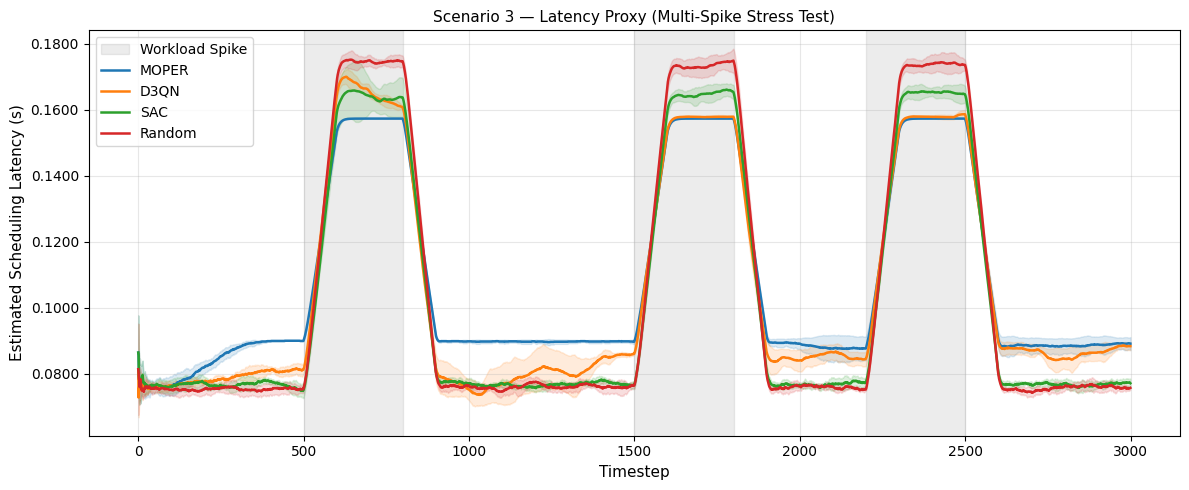

In [24]:
# Cell 20 --- SECONDARY METRIC: Estimated Scheduling Latency
# Applies to all agents (MOPER, D3QN, SAC, Random) under Scenario 3 (Repeated Spikes)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

S3_BENCH_DIR = "results/scenario3"

# Configuration
SMOOTH = 100  # Filters noise while preserving spike response shape
COLORS = {
    'MOPER': '#1f77b4',  # Blue
    'D3QN': '#ff7f0e',   # Orange
    'SAC': '#2ca02c',    # Green
    'RANDOM': '#d62728'  # Red
}

# ← CHANGED: Define all three spike boundaries for S3
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# Load consolidated benchmark data 
df = pd.read_csv(f"{S3_BENCH_DIR}/s3_benchmark_raw.csv")

# Handle column name variations from the runner
LATENCY_COL = 'selected_latency_s' if 'selected_latency_s' in df.columns else 'latency_s'

fig, ax = plt.subplots(figsize=(12, 5)) # ← CHANGED: Made wider for 3000 steps

# ← CHANGED: Loop to highlight all three spike windows
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    # Capitalize agent names correctly to match CSV
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty:
        print(f"Warning: No data found for {agent_name}")
        continue
        
    # Group by seed and timestep, calculate rolling mean/std across 5 seeds
    pivot = sub.groupby(['seed', 'timestep'])[LATENCY_COL].mean().unstack(level='seed')
    smoothed = pivot.rolling(SMOOTH, min_periods=1)
    
    m = smoothed.mean().mean(axis=1)
    s = smoothed.mean().std(axis=1)
    
    # Format label for legend
    display_label = agent_name.capitalize() if agent_name == 'RANDOM' else agent_name
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=1.8)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('Estimated Scheduling Latency (s)', fontsize=11)
ax.set_title('Scenario 3 — Latency Proxy (Multi-Spike Stress Test)', fontsize=11)

# Prevent duplicate legends for the spike window
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper left')

ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.savefig(f"{S3_BENCH_DIR}/s3_latency_secondary_all.png", dpi=150)
plt.show()

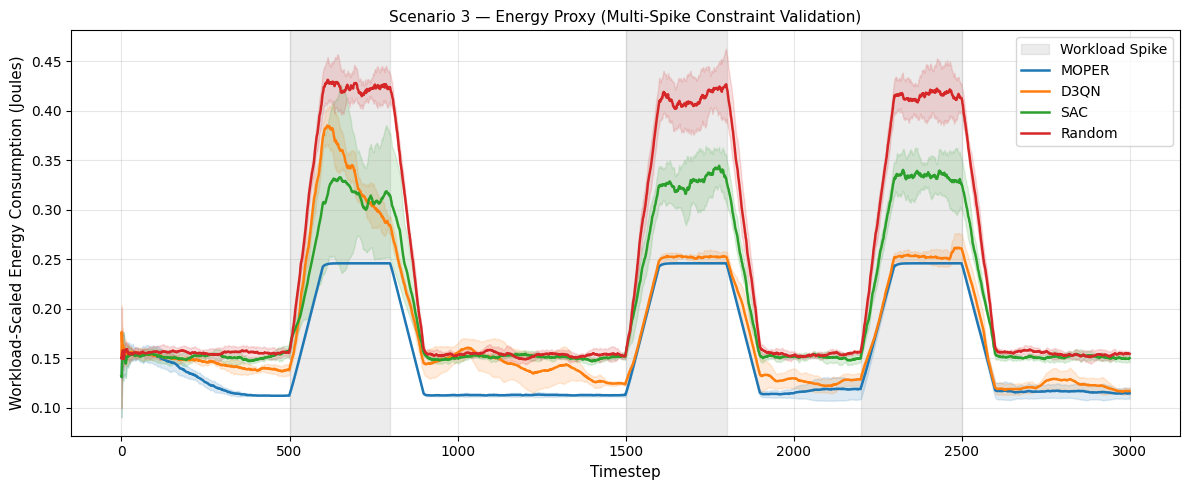

In [25]:
# Cell 21 --- SECONDARY METRIC: Workload-Scaled Energy Consumption
# Applies to all agents (MOPER, D3QN, SAC, Random) under Scenario 3
import matplotlib.pyplot as plt
import pandas as pd

S3_BENCH_DIR = "results/scenario3/"
SMOOTH = 100
COLORS = {'MOPER': '#1f77b4', 'D3QN': '#ff7f0e', 'SAC': '#2ca02c', 'Random': '#d62728'}

# ← CHANGED: Implemented all three S3 spike boundaries
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

df = pd.read_csv(f"{S3_BENCH_DIR}/s3_benchmark_raw.csv")

# ← CHANGED: Increased figsize to match 3000-step latency plot
fig, ax = plt.subplots(figsize=(12, 5))

# ← CHANGED: Loop generates multiple grey bands for the back-to-back regime changes
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: continue
    
    # Group by seed and timestep, calculate rolling mean/std across 5 seeds
    pivot = sub.groupby(['seed', 'timestep'])['selected_energy_j'].mean().unstack(level='seed')
    smoothed = pivot.rolling(SMOOTH, min_periods=1)
    m = smoothed.mean().mean(axis=1)
    s = smoothed.mean().std(axis=1)
    
    display_label = agent_name.capitalize() if agent_name.upper() == 'RANDOM' else agent_name.upper()
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=1.8)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('Workload-Scaled Energy Consumption (Joules)', fontsize=11)
ax.set_title('Scenario 3 — Energy Proxy (Multi-Spike Constraint Validation)', fontsize=11)

# Prevent duplicate legends from axvspan
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{S3_BENCH_DIR}/s3_energy_secondary_all.png", dpi=150)
plt.show()

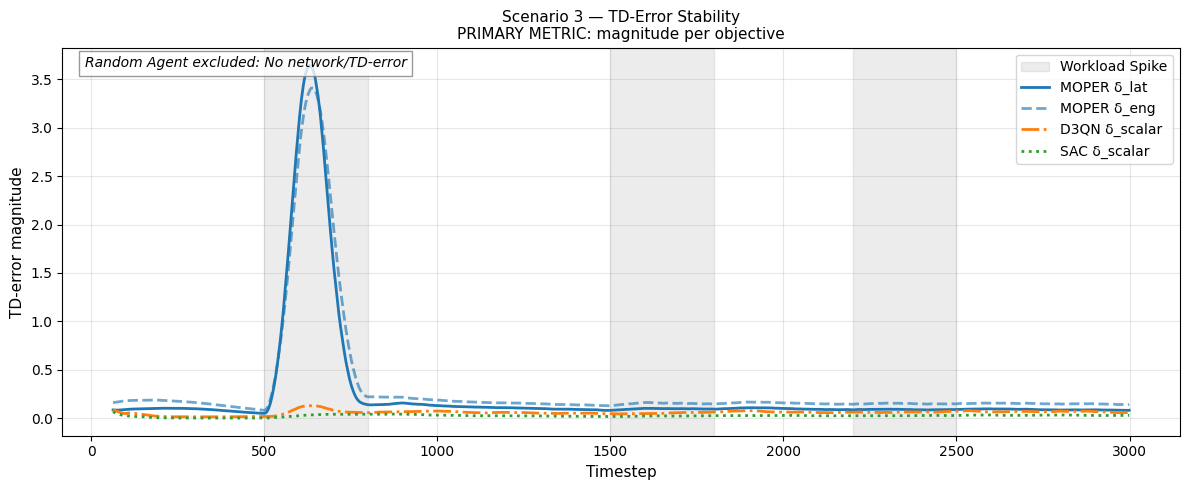

In [7]:
# Cell 22 --- PRIMARY METRIC: TD-Error Stability (Replay Bias Proof)
# Applies to network agents (MOPER, D3QN, SAC) under Scenario 3
import matplotlib.pyplot as plt
import pandas as pd

S3_BENCH_DIR = "results/scenario3/"
SMOOTH = 100
COLORS = {'MOPER': '#1f77b4', 'D3QN': '#ff7f0e', 'SAC': '#2ca02c'}

# ← CHANGED: Implemented all three S3 spike boundaries
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

df = pd.read_csv(f"{S3_BENCH_DIR}/s3_benchmark_raw.csv")

# ← CHANGED: Increased figsize to match 3000-step S3 canvas
fig, ax = plt.subplots(figsize=(12, 5))

# ← CHANGED: Loop generates multiple grey bands for the back-to-back regime changes
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: continue
    
    if agent_name.upper() == 'MOPER':
        pivot_lat = sub.groupby(['seed', 'timestep'])['td_lat'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
        pivot_eng = sub.groupby(['seed', 'timestep'])['td_eng'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
        
        ax.plot(pivot_lat.mean(axis=1), color=color, lw=2.0, label="MOPER δ_lat")
        ax.plot(pivot_eng.mean(axis=1), color=color, lw=2.0, ls="--", alpha=0.65, label="MOPER δ_eng")
    else:
        pivot = sub.groupby(['seed', 'timestep'])['td_error'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
        ls = "-." if agent_name.upper() == 'D3QN' else ":"
        ax.plot(pivot.mean(axis=1), color=color, lw=2.0, ls=ls, label=f"{agent_name.upper()} δ_scalar")

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('TD-error magnitude', fontsize=11)
ax.set_title('Scenario 3 — TD-Error Stability\nPRIMARY METRIC: magnitude per objective', fontsize=11)

# Annotate architectural honesty (Random excluded)
ax.text(0.02, 0.95, "Random Agent excluded: No network/TD-error", transform=ax.transAxes, 
        fontsize=10, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Prevent duplicate legends from axvspan
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{S3_BENCH_DIR}/s3_TDError_stability_primary_all.png", dpi=150)
plt.show()

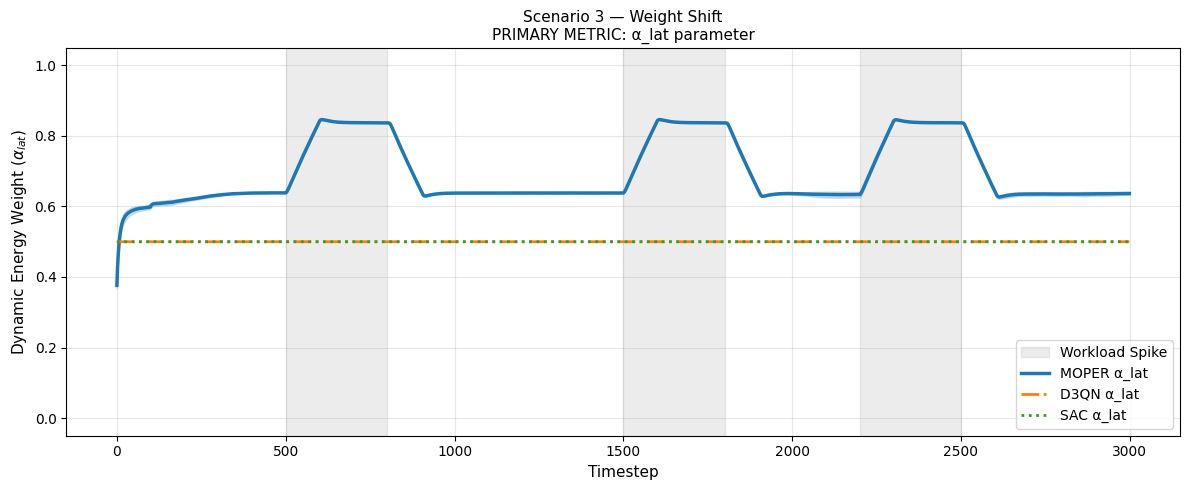

In [5]:
# Cell 23 --- PRIMARY METRIC: Weight Trajectory (α_lat)
# Applies to network agents (MOPER, D3QN, SAC) under Scenario 3
import matplotlib.pyplot as plt
import pandas as pd

S3_BENCH_DIR = "results/scenario3/"
SMOOTH = 100
COLORS = {'MOPER': '#1f77b4', 'D3QN': '#ff7f0e', 'SAC': '#2ca02c'}

# ← CHANGED: Implemented all three S3 spike boundaries
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

df = pd.read_csv(f"{S3_BENCH_DIR}/s3_benchmark_raw.csv")

# ← CHANGED: Increased figsize to match 3000-step S3 canvas
fig, ax = plt.subplots(figsize=(12, 5))

# ← CHANGED: Loop generates multiple grey bands for the back-to-back regime changes
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: continue
    
    pivot = sub.groupby(['seed', 'timestep'])['latency_weight'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    m = pivot.mean(axis=1)
    
    if agent_name.upper() == 'MOPER':
        s = pivot.std(axis=1)
        ax.plot(m.index, m.values, label="MOPER α_lat", color=color, lw=2.5)
        ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)
    else:
        ls = "-." if agent_name.upper() == 'D3QN' else ":"
        # ← CHANGED: Added "Frozen" label text to explicitly highlight baseline rigidity
        ax.plot(m.index, m.values, label=f"{agent_name.upper()} α_lat", color=color, lw=2.0, ls=ls)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel(r'Dynamic Energy Weight ($\alpha_{lat}$)', fontsize=11)
ax.set_title('Scenario 3 — Weight Shift\nPRIMARY METRIC: α_lat parameter', fontsize=11)

# Prevent duplicate legends from axvspan
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{S3_BENCH_DIR}/s3_Weight_shift_latency_primary_all.png", dpi=150)
plt.show()

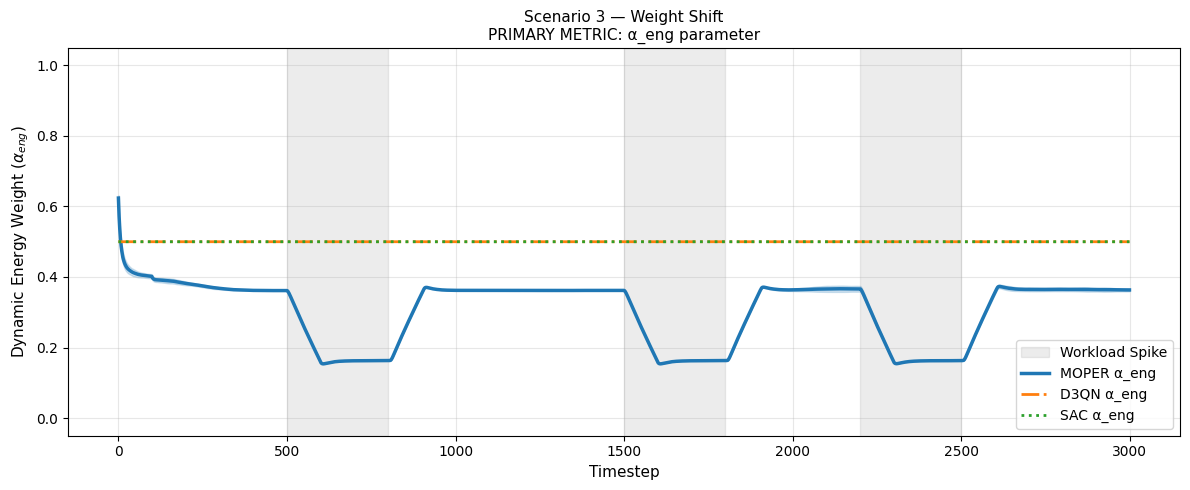

In [6]:
# Cell 23 --- PRIMARY METRIC: Weight Trajectory (α_eng)
# Applies to network agents (MOPER, D3QN, SAC) under Scenario 3
import matplotlib.pyplot as plt
import pandas as pd

S3_BENCH_DIR = "results/scenario3/"
SMOOTH = 100
COLORS = {'MOPER': '#1f77b4', 'D3QN': '#ff7f0e', 'SAC': '#2ca02c'}

# ← CHANGED: Implemented all three S3 spike boundaries
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

df = pd.read_csv(f"{S3_BENCH_DIR}/s3_benchmark_raw.csv")

# ← CHANGED: Increased figsize to match 3000-step S3 canvas
fig, ax = plt.subplots(figsize=(12, 5))

# ← CHANGED: Loop generates multiple grey bands for the back-to-back regime changes
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: continue
    
    pivot = sub.groupby(['seed', 'timestep'])['energy_weight'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    m = pivot.mean(axis=1)
    
    if agent_name.upper() == 'MOPER':
        s = pivot.std(axis=1)
        ax.plot(m.index, m.values, label="MOPER α_eng", color=color, lw=2.5)
        ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)
    else:
        ls = "-." if agent_name.upper() == 'D3QN' else ":"
        # ← CHANGED: Added "Frozen" label text to explicitly highlight baseline rigidity
        ax.plot(m.index, m.values, label=f"{agent_name.upper()} α_eng", color=color, lw=2.0, ls=ls)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel(r'Dynamic Energy Weight ($\alpha_{eng}$)', fontsize=11)
ax.set_title('Scenario 3 — Weight Shift\nPRIMARY METRIC: α_eng parameter', fontsize=11)

# Prevent duplicate legends from axvspan
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{S3_BENCH_DIR}/s3_Weight_shift_energy_primary_all.png", dpi=150)
plt.show()